<a href="https://colab.research.google.com/github/marianoInsa/dimiasa-models/blob/main/notebooks/06_E03_Preparacion_Final_100Hz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento 3: Preparación Final de Datasets (100 Hz)

**Objetivo:** Pipeline definitivo de generación de métricas por trial, filtrado de calidad, resampleo y partición antes del entrenamiento del modelo CNN-LSTM.

Este notebook reemplaza la dependencia de `RESULTS` en memoria (generado por E02 en la misma sesión de Colab) por un cálculo de métricas **por trial** integrado en este mismo experimento, persistido en Azure (`plata/falls/`). Produce:

- `resampling_metrics_per_trial_100hz.csv` — métricas por trial (Pearson, SNR, DTW, phase shift, atenuación) → `plata/falls/`
- `trial_quality_config.json` — IDs de trials válidos por dataset → `plata/falls/`
- `subject_split_config.json` — asignación de sujetos a Train/Val/Test → `plata/falls/`
- Parquet resampleados a 100 Hz en `oro/falls/dataset=<nombre>/` en Azure

**Secciones:**
1. Validación de integridad de etiquetas
2. Generación de métricas por trial (100 Hz) y persistencia en `plata/falls/`
3. Filtrado de trials por calidad de resampleo
4. Resampleo definitivo y guardado en Parquet
5. Split por sujeto y análisis de balance

**Decisión de frecuencia (registro):** se evaluaron 50 Hz y 100 Hz en el Experimento 2.
A 100 Hz, SisFall pasa de atenuación de pico P95 de 102–353 % a ~13 %, y FallAllD de
Pearson r medio 0.82–0.87 a 0.92–0.94 (cruzando el umbral de descarte de 0.85). KFall y
UPFall ya estaban nativamente a 100 Hz, por lo que no sufren ninguna degradación por
resampleo. Se decidió **100 Hz** como frecuencia objetivo final.

> **Nota de diseño — por qué se recalculan las métricas por trial en este notebook:**
> El CSV `resampling_validation_results_100hz.csv` (en `plata/falls/`) contiene el
> resumen agregado por dataset+sensor (media/P95) usado para la decisión 50 vs 100 Hz.
> Es deliberadamente un agregado y **no permite filtrar trials individuales** — los
> outliers puntuales que el propio E02 documentó (p. ej. picos de atenuación de hasta
> 353 % en SisFall a 50 Hz) quedan diluidos en la media. El filtrado de la Sección 3
> necesita granularidad de trial, así que la Sección 2 reconstruye esas métricas por
> trial, reutilizando exactamente las mismas funciones de E02 (banda de referencia
> Butterworth orden 8, corte paramétrico en `FS_TARGET/2 − 0.5`, con bypass automático
> si `fs_orig` ya está por debajo de eso) pero ahora con `FS_TARGET = 100` y conservando
> el ID de cada trial junto a sus métricas — E02 no lo hacía, y reconstruir esa
> correspondencia por orden de iteración era una fuente de bugs latente.


## 0 · Instalación y librerías

In [4]:
%pip install numpy pandas scipy pyarrow dtaidistance azure-storage-file-datalake --quiet

In [5]:
import io
import json
import warnings
import math
from datetime import datetime, timezone
from math import gcd

import numpy as np
import pandas as pd
from scipy.signal import resample_poly, butter, filtfilt
from scipy.stats import pearsonr
from dtaidistance import dtw as dtw_lib
from google.colab import userdata
from azure.storage.filedatalake import DataLakeServiceClient

#warnings.filterwarnings("ignore")

# --- Constantes globales ------------------------------------------------------
FS_TARGET      = 100    # 100 Hz
KAISER_BETA    = 5.0    # Parámetro de forma (ventana Kaiser)
EVAL_WINDOW_SEC = 2.0   # ventana de segundos alrededor del pico
WINDOW_SAMPLES = 200    # 2s × 100 Hz
OVERLAP_STEP   = 100    # 200 × 50 % (overlap)
FALL_LABEL_THR = 0.30   # umbral para etiquetar ventana como Fall

# Umbrales de descarte según métricas
THR_PEARSON_MIN    = 0.85
THR_PHASE_MS_MAX   = 100.0
THR_ATTEN_PCT_MAX  = 25.0

DATASETS_META = {
    "UPFall":   {"fs": 100,  "csv": "UPFall-Reduced.csv"},
    "KFall":    {"fs": 100,  "csv": "KFall-Reduced.csv"},
    "FallAllD": {"fs": 238,  "csv": "FallAllD-Reduced.csv"},
    "SisFall":  {"fs": 200,  "csv": "SisFall-Reduced.csv"},
}

SPLIT_RATIOS = {"train": 0.70, "val": 0.10, "test": 0.20}

print("Configuración:")
print(f"  FS_TARGET          = {FS_TARGET} Hz")
print(f"  KAISER_BETA        = {KAISER_BETA}")
print(f"  WINDOW_SAMPLES     = {WINDOW_SAMPLES}  ({WINDOW_SAMPLES/FS_TARGET:.1f} s)")
print(f"  OVERLAP_STEP       = {OVERLAP_STEP}  ({OVERLAP_STEP/FS_TARGET:.1f} s)")
print(f"  FALL_LABEL_THR     = {FALL_LABEL_THR*100:.0f} %")
print(f"  Umbral Pearson r   ≥ {THR_PEARSON_MIN}")
print(f"  Umbral phase shift ≤ {THR_PHASE_MS_MAX} ms")
print(f"  Umbral atenuación  ≤ {THR_ATTEN_PCT_MAX} %")

Configuración:
  FS_TARGET          = 100 Hz
  KAISER_BETA        = 5.0
  WINDOW_SAMPLES     = 200  (2.0 s)
  OVERLAP_STEP       = 100  (1.0 s)
  FALL_LABEL_THR     = 30 %
  Umbral Pearson r   ≥ 0.85
  Umbral phase shift ≤ 100.0 ms
  Umbral atenuación  ≤ 25.0 %


## 1 · Validación de integridad de etiquetas

Verifica que `Activity_Label` contenga únicamente `"Fall"` y `"ADL"`, que no haya trials
con mezcla incoherente de etiquetas, y obtiene la distribución base de trials por dataset
antes de aplicar ningún filtro.

In [6]:
# --- Conexión a Azure ---------------------------------------------------------
CONNECTION_STRING = userdata.get("cadenaAzure")
service_client    = DataLakeServiceClient.from_connection_string(CONNECTION_STRING)
fs_bronce         = service_client.get_file_system_client("bronce")
dir_falls_bronze  = fs_bronce.get_directory_client("falls")

def _load_csv_bronze(filename: str) -> pd.DataFrame | None:
    try:
        content = dir_falls_bronze.get_file_client(filename).download_file().readall()
        df = pd.read_csv(io.BytesIO(content))
        print(f"  ✓  {filename:35s}  →  {len(df):>8,} filas")
        return df
    except Exception as e:
        print(f"  ✗  {filename:35s}  →  ERROR: {e}")
        return None

print("Descargando datasets desde bronce…")
raw_datasets: dict[str, pd.DataFrame] = {}
for ds_name, meta in DATASETS_META.items():
    df = _load_csv_bronze(meta["csv"])
    if df is not None:
        raw_datasets[ds_name] = df

print(f"\nDatasets cargados: {list(raw_datasets.keys())}")

Descargando datasets desde bronce…
  ✓  UPFall-Reduced.csv                   →   294,678 filas
  ✓  KFall-Reduced.csv                    →  3,995,100 filas
  ✓  FallAllD-Reduced.csv                 →  8,558,480 filas
  ✓  SisFall-Reduced.csv                  →  15,858,929 filas

Datasets cargados: ['UPFall', 'KFall', 'FallAllD', 'SisFall']


In [7]:
VALID_LABELS = {"Fall", "ADL"}

label_issues    = {}   # datasets con valores inesperados
mixed_issues    = {}   # trials con mezcla incoherente
label_dist_rows = []   # distribución base

for ds_name, df in raw_datasets.items():
    unique_labels = set(df["Activity_Label"].unique())
    unexpected    = unique_labels - VALID_LABELS

    if unexpected:
        label_issues[ds_name] = unexpected

    # Detectar trials donde el mismo (Subject, Activity_Code, Trial)
    # tiene filas de ambas etiquetas — anomalía potencial en Fall trials
    trials = df.groupby(["Subject", "Activity_Code", "Trial"])["Activity_Label"].nunique()
    mixed  = trials[trials > 1]
    if not mixed.empty:
        mixed_issues[ds_name] = mixed

    # Distribución base: trials únicos por label
    trial_ids = df.groupby(
        ["Subject", "Activity_Code", "Trial"]
    )["Activity_Label"].first().reset_index()

    for label in ("Fall", "ADL"):
        n = (trial_ids["Activity_Label"] == label).sum()
        label_dist_rows.append({
            "Dataset": ds_name,
            "Label":   label,
            "Trials":  n
        })

# --- Informe ------------------------------------------------------------------
print("=" * 60)
print("  RESULTADO: Integridad de etiquetas")
print("=" * 60)

if label_issues:
    print("\n  ⚠️  Valores inesperados en Activity_Label:")
    for ds, vals in label_issues.items():
        print(f"     {ds}: {vals}")
else:
    print("\n  ✅  Todos los datasets contienen únicamente 'Fall' y 'ADL'.")

if mixed_issues:
    print("\n  ⚠️  Trials con mezcla de etiquetas Fall+ADL:")
    for ds, mixed in mixed_issues.items():
        print(f"     {ds}: {len(mixed)} trial(s) afectados")
        print(mixed.head(5).to_string())
else:
    print("  ✅  Sin trials con mezcla incoherente de etiquetas.")

print("\n  Distribución base de trials por dataset:")
df_dist = pd.DataFrame(label_dist_rows).pivot(
    index="Dataset", columns="Label", values="Trials"
).fillna(0).astype(int)
df_dist["Total"] = df_dist.sum(axis=1)
df_dist["Ratio ADL/Fall"] = (df_dist.get("ADL", 0) / df_dist.get("Fall", 1)).round(2)
print(df_dist.to_string())

  RESULTADO: Integridad de etiquetas

  ✅  Todos los datasets contienen únicamente 'Fall' y 'ADL'.
  ✅  Sin trials con mezcla incoherente de etiquetas.

  Distribución base de trials por dataset:
Label      ADL  Fall  Total  Ratio ADL/Fall
Dataset                                    
FallAllD  1332   466   1798            2.86
KFall     2729  2346   5075            1.16
SisFall   2707  1798   4505            1.51
UPFall     304   255    559            1.19


## 2 · Generación de métricas por trial (100 Hz) y persistencia en `plata/falls/`

Recalcula, para cada trial Fall de cada dataset, las cinco métricas de fidelidad de
resampleo definidas en el Experimento 2 (SNR in-band, Pearson r, DTW normalizado,
phase shift, atenuación de pico), ahora a `FS_TARGET = 100 Hz`. Las funciones son una
copia fiel de las usadas en `E02-Resampleo-Unificado (100 Hz)` — **no se modificó la
lógica de cálculo**, solo se agregó la captura del ID de trial (`Subject`,
`Activity_Code`, `Trial`) junto a cada fila de métricas, algo que E02 no hacía.

**Referencia de comparación:** señal original filtrada con Butterworth orden 8 al
ancho de banda del target (`FS_TARGET/2 − 0.5` Hz), con bypass automático cuando esa
banda ya cubre el Nyquist de la señal original (`fs_orig` ≤ `FS_TARGET`). Esto es
paramétrico en `FS_TARGET` — al cambiar la constante de 50 a 100, la referencia se
recalcula automáticamente a ~49 Hz en vez de ~24.5 Hz; no requirió tocar la función.

Dataset/sensor con KFall y UPFall (ya a 100 Hz) **no se procesan acá**: al no haber
resampleo real (`fs_orig == FS_TARGET`), las métricas de fidelidad no aplican — se
trata como degradación 0 / sin descarte para esos dos datasets en la Sección 3.

In [8]:
# --- Filtro pasa-bajos de Butterworth (idéntico a E02) ------------------------
def lowpass(signal: np.ndarray, fs: int, cutoff: float = None) -> np.ndarray:
    """
    Filtra la señal original al mismo ancho de banda que la señal resampleada
    (Nyquist del target = FS_TARGET/2). Permite comparar señales en la misma
    banda antes de calcular correlación/SNR, eliminando la ventaja artificial
    de la señal original al tener contenido de alta frecuencia.
    """
    if cutoff is None:
        cutoff = FS_TARGET / 2.0 - 0.5   # ligeramente por debajo de Nyquist
    nyq = fs / 2.0

    # Si la señal original ya está limitada por debajo de la frecuencia de corte
    # (fs_orig <= FS_TARGET), no tiene sentido filtrar: devolver la señal tal cual
    if cutoff >= nyq * 0.99:
        return signal.copy()
    b, a = butter(8, cutoff / nyq, btype="low")
    return filtfilt(b, a, signal)


def get_poly_factors(fs_orig: int, fs_target: int) -> tuple[int, int]:
    """Devuelve (up, down) reducidos al mínimo común divisor."""
    g = gcd(fs_target, fs_orig)
    return fs_target // g, fs_orig // g


def resample_trial(signal: np.ndarray, fs_orig: int, fs_target: int) -> np.ndarray:
    """Resamplea un trial COMPLETO con resample_poly y filtro Kaiser consistente."""
    up, down = get_poly_factors(fs_orig, fs_target)
    return resample_poly(signal, up=up, down=down, window=("kaiser", KAISER_BETA))


# --- Métricas (idénticas a E02) -----------------------------------------------
def snr_inband(orig: np.ndarray, resampled: np.ndarray,
               fs_orig: int, fs_target: int) -> float:
    """SNR en la banda válida [0, FS_TARGET/2] Hz."""
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)

    orig_filtered = lowpass(orig, fs_orig)
    noise = orig_filtered - resampled_interp
    power_signal = np.mean(orig_filtered ** 2)
    power_noise  = np.mean(noise ** 2)
    if power_noise == 0:
        return np.inf
    return 10 * np.log10(power_signal / power_noise)


def pearson_inband(orig: np.ndarray, resampled: np.ndarray, fs_orig: int) -> float:
    """Correlación de Pearson entre la original filtrada y la resampleada."""
    n_orig = len(orig)
    n_res  = len(resampled)
    t_orig = np.linspace(0, 1, n_orig)
    t_res  = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    orig_filtered    = lowpass(orig, fs_orig)
    r, _ = pearsonr(orig_filtered, resampled_interp)
    return r


def dtw_normalized(orig: np.ndarray, resampled: np.ndarray,
                   fs_orig: int, fs_target: int) -> float:
    """Distancia DTW normalizada por la longitud de la secuencia más larga."""
    up, down = get_poly_factors(fs_orig, fs_target)
    orig_resampled_to_target = resample_poly(orig, up=up, down=down,
                                              window=("kaiser", KAISER_BETA))

    def zscore(x):
        s = x.std()
        return (x - x.mean()) / s if s > 0 else x - x.mean()

    a = zscore(orig_resampled_to_target).astype(np.double)
    b = zscore(resampled).astype(np.double)
    max_len = 500
    if len(a) > max_len:
        a = a[:max_len]
        b = b[:max_len]
    dist = dtw_lib.distance_fast(a, b)
    return dist / max(len(a), len(b))


def peak_phase_shift_ms(orig: np.ndarray, resampled: np.ndarray,
                         fs_orig: int, fs_target: int) -> float:
    """Desfase temporal entre el pico de la original y el de la resampleada, en ms."""
    t_peak_orig = orig.argmax() / fs_orig
    t_peak_res  = resampled.argmax() / fs_target
    return abs(t_peak_orig - t_peak_res) * 1000


def peak_attenuation_pct(orig: np.ndarray, resampled: np.ndarray, fs_orig: int) -> float:
    """Atenuación del pico relativa a la señal original filtrada."""
    orig_filtered = lowpass(orig, fs_orig)
    max_orig = np.max(orig_filtered)
    n_res    = len(resampled)
    n_orig   = len(orig)
    t_orig   = np.linspace(0, 1, n_orig)
    t_res    = np.linspace(0, 1, n_res)
    resampled_interp = np.interp(t_orig, t_res, resampled)
    max_res  = np.max(resampled_interp)
    return abs(max_orig - max_res) / max_orig * 100 if max_orig > 0 else 0.0


print("Funciones de métricas cargadas (idénticas a E02, FS_TARGET ahora paramétrico = 100 Hz).")

Funciones de métricas cargadas (idénticas a E02, FS_TARGET ahora paramétrico = 100 Hz).


In [9]:
# --- Pipeline de análisis por trial, con captura explícita de ID --------------
def analyze_trial(trial_df: pd.DataFrame, fs_orig: int,
                  fs_target: int = FS_TARGET) -> dict | None:
    """
    Analiza un trial completo:
      1. Calcula las resultantes de acelerómetro y giroscopio
      2. Resamplea el trial COMPLETO
      3. Extrae ventana focal alrededor del pico (en la señal resampleada)
      4. Calcula las 5 métricas para cada sensor
    """
    a_res = np.sqrt(trial_df["Ax"]**2 + trial_df["Ay"]**2 + trial_df["Az"]**2).values
    g_res = np.sqrt(trial_df["Gx"]**2 + trial_df["Gy"]**2 + trial_df["Gz"]**2).values

    if len(a_res) < fs_orig:   # trial demasiado corto
        return None

    a_res_r = resample_trial(a_res, fs_orig, fs_target)
    g_res_r = resample_trial(g_res, fs_orig, fs_target)

    w = int(EVAL_WINDOW_SEC / 2 * fs_target)
    peak_r = a_res_r.argmax()
    s, e = max(0, peak_r - w), min(len(a_res_r), peak_r + w)

    peak_o = a_res.argmax()
    wo = int(EVAL_WINDOW_SEC / 2 * fs_orig)
    so, eo = max(0, peak_o - wo), min(len(a_res), peak_o + wo)

    win_a_orig = a_res[so:eo]
    win_a_res  = a_res_r[s:e]
    win_g_orig = g_res[so:eo]
    win_g_res  = g_res_r[s:e]

    result = {}
    for sensor, orig, resampled in [("acc", win_a_orig, win_a_res),
                                     ("gyro", win_g_orig, win_g_res)]:
        result[sensor] = {
            "snr_db":          snr_inband(orig, resampled, fs_orig, fs_target),
            "pearson_r":       pearson_inband(orig, resampled, fs_orig),
            "dtw_norm":        dtw_normalized(orig, resampled, fs_orig, fs_target),
            "phase_shift_ms":  peak_phase_shift_ms(orig, resampled, fs_orig, fs_target),
            "peak_atten_pct":  peak_attenuation_pct(orig, resampled, fs_orig),
        }
    return result


def run_trial_metrics(df: pd.DataFrame, fs_orig: int,
                       label: str = "Fall") -> pd.DataFrame:
    """
    Itera sobre todos los trials de la clase indicada y devuelve un DataFrame
    con las métricas por trial — A DIFERENCIA de run_global_validation en E02,
    cada fila incluye Subject/Activity_Code/Trial explícitos, eliminando la
    necesidad de reconstruir la correspondencia por orden de iteración.
    """
    falls  = df[df["Activity_Label"] == label]
    trials = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates()
    print(f"  Procesando {len(trials)} trials ({label})…")

    rows = []
    n_done = 0
    for _, row in trials.iterrows():
        mask = ((falls["Subject"]       == row["Subject"]) &
                (falls["Activity_Code"] == row["Activity_Code"]) &
                (falls["Trial"]         == row["Trial"]))
        trial_df = falls[mask]
        r = analyze_trial(trial_df, fs_orig)
        n_done += 1
        if r is None:
            continue
        for sensor in ("acc", "gyro"):
            rows.append({
                "Subject":       row["Subject"],
                "Activity_Code": row["Activity_Code"],
                "Trial":         row["Trial"],
                "sensor":        sensor,
                **r[sensor],
            })
        if n_done % 200 == 0 or n_done == len(trials):
            print(f"  Progreso: {n_done}/{len(trials)} trials", end="\r")
    print()
    return pd.DataFrame(rows)


print("Pipeline de métricas por trial cargado.")

Pipeline de métricas por trial cargado.


In [11]:
# --- Ejecutar generación de métricas por trial para todos los datasets --------
# KFall y UPFall ya están a 100 Hz (fs_orig == FS_TARGET): no hay resampleo real,
# así que no se calculan métricas de fidelidad para ellos — se documentan aparte
# y se tratan como "sin degradación" en la Sección 3.

RESULTS: dict[str, dict] = {}

for ds_name, meta in DATASETS_META.items():
    if ds_name not in raw_datasets:
        print(f"[{ds_name}] OMITIDO — no disponible en memoria")
        continue

    fs_orig = meta["fs"]

    if fs_orig == FS_TARGET:
        print(f"[{ds_name}]  {fs_orig} Hz == FS_TARGET — sin resampleo real, "
              f"se omite cálculo de métricas de fidelidad")
        continue

    print(f"\n[{ds_name}]  {fs_orig} Hz → {FS_TARGET} Hz")
    df_metrics = run_trial_metrics(raw_datasets[ds_name], fs_orig)
    RESULTS[ds_name] = {"metrics": df_metrics, "fs_orig": fs_orig}
    print(f"  Filas de métricas generadas: {len(df_metrics):,}")

print("\n" + "="*55)
print("  Generación de métricas por trial completada.")
print(f"  Datasets con métricas calculadas: {list(RESULTS.keys())}")

[UPFall]  100 Hz == FS_TARGET — sin resampleo real, se omite cálculo de métricas de fidelidad
[KFall]  100 Hz == FS_TARGET — sin resampleo real, se omite cálculo de métricas de fidelidad

[FallAllD]  238 Hz → 100 Hz
  Procesando 466 trials (Fall)…
  Progreso: 466/466 trials
  Filas de métricas generadas: 932

[SisFall]  200 Hz → 100 Hz
  Procesando 1798 trials (Fall)…
  Progreso: 1798/1798 trials
  Filas de métricas generadas: 3,596

  Generación de métricas por trial completada.
  Datasets con métricas calculadas: ['FallAllD', 'SisFall']


In [12]:
# --- Persistir métricas por trial en plata/falls/ -----------------------------
# Se sube a Azure como CSV consolidado, con una columna Dataset para poder filtrar por origen.

fs_plata        = service_client.get_file_system_client("plata")
dir_plata_falls = fs_plata.get_directory_client("falls")

per_trial_filename = f"resampling_metrics_per_trial_{FS_TARGET}hz.csv"

df_metrics_all = pd.concat(
    [df["metrics"].assign(Dataset=ds_name) for ds_name, df in RESULTS.items()],
    ignore_index=True
)

csv_buffer = io.StringIO()
df_metrics_all.to_csv(csv_buffer, index=False)

file_client = dir_plata_falls.get_file_client(per_trial_filename)
file_client.upload_data(csv_buffer.getvalue(), overwrite=True)

print(f"✅  {per_trial_filename} subido a plata/falls/  "
      f"({len(df_metrics_all):,} filas, {csv_buffer.tell():,} bytes)")
print(df_metrics_all.groupby("Dataset").size().to_string())

✅  resampling_metrics_per_trial_100hz.csv subido a plata/falls/  (4,528 filas, 508,352 bytes)
Dataset
FallAllD     932
SisFall     3596


## 3 · Filtrado de trials por calidad de resampleo

Usa el DataFrame de métricas por trial generado en la Sección 2 (ya en memoria como
`RESULTS`, y persistido en `plata/falls/`) para identificar los trials que superan los
umbrales de descarte y genera `trial_quality_config.json`.

**Criterio de descarte (lógica OR — basta una condición):**
- ACC Pearson r < 0.85
- ACC phase_shift_ms > 100 ms
- ACC peak_atten_pct > 25 %

> Los criterios se aplican únicamente sobre ACC. El giroscopio es ruidoso en algunos
> datasets (especialmente FallAllD) y sus métricas de fase no son diagnóstico fiable
> del desplazamiento del evento de impacto.

**Cambio respecto al pipeline de 50 Hz:** el cruce entre trial y sus métricas ya no se
reconstruye por orden de iteración (frágil — dependía de que el orden de `groupby` en
Sección 2 coincidiera exactamente con el orden de `drop_duplicates` aquí). Ahora se hace
con un `merge` explícito sobre `(Subject, Activity_Code, Trial)`, que es la columna que
la Sección 2 ya captura. KFall y UPFall no tienen entrada en `RESULTS` (no fueron
resampleados, ver Sección 2) — sus trials se consideran válidos por definición.

In [13]:
# --- Función: generar lista de IDs válidos para un dataset --------------------
def filter_valid_trials(
    df_raw: pd.DataFrame,
    df_metrics_acc: pd.DataFrame,
    pearson_min: float = THR_PEARSON_MIN,
    phase_ms_max: float = THR_PHASE_MS_MAX,
    atten_pct_max: float = THR_ATTEN_PCT_MAX,
) -> tuple[list, int, int]:
    """
    Cruza los trials Fall del CSV raw con sus métricas de ACC mediante un merge
    explícito por (Subject, Activity_Code, Trial) — ya no por orden de iteración.

    Retorna (valid_ids, n_valid, n_discarded) donde valid_ids es una lista
    de [Subject, Activity_Code, Trial] de los trials que pasan los umbrales.
    """
    falls = df_raw[df_raw["Activity_Label"] == "Fall"]
    trial_ids = (
        falls[["Subject", "Activity_Code", "Trial"]]
        .drop_duplicates()
        .reset_index(drop=True)
    )

    acc_metrics = df_metrics_acc[
        ["Subject", "Activity_Code", "Trial", "pearson_r", "phase_shift_ms", "peak_atten_pct"]
    ]

    merged = trial_ids.merge(
        acc_metrics, on=["Subject", "Activity_Code", "Trial"], how="left"
    )

    n_missing = merged["pearson_r"].isna().sum()
    if n_missing:
        print(
            f"  ⚠️  {n_missing} trial(s) sin métricas asociadas (no se pudieron "
            f"resamplear o quedaron fuera de Sección 2) — se descartan por seguridad."
        )

    discard_mask = (
        merged["pearson_r"].isna() |
        (merged["pearson_r"]      < pearson_min)  |
        (merged["phase_shift_ms"] > phase_ms_max) |
        (merged["peak_atten_pct"] > atten_pct_max)
    )

    valid_ids = (
        merged.loc[~discard_mask, ["Subject", "Activity_Code", "Trial"]]
        .values.tolist()
    )

    n_valid     = len(valid_ids)
    n_discarded = int(discard_mask.sum())

    return valid_ids, n_valid, n_discarded


print("Función de filtrado cargada (merge explícito por ID de trial).")

Función de filtrado cargada (merge explícito por ID de trial).


In [14]:
# --- Generar config de calidad por dataset ------------------------------------
quality_config = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "fs_target":    FS_TARGET,
    "criteria": {
        "pearson_r_min":      THR_PEARSON_MIN,
        "phase_shift_ms_max": THR_PHASE_MS_MAX,
        "peak_atten_pct_max": THR_ATTEN_PCT_MAX,
    },
    "datasets": {}
}

print("Filtrando trials por calidad de resampleo…\n")
print(f"  {'Dataset':12s}  {'Total':>7}  {'Válidos':>8}  {'Descartados':>12}  {'% Descarte':>10}")
print("  " + "-" * 55)

for ds_name, meta in DATASETS_META.items():
    if ds_name not in raw_datasets:
        print(f"  {ds_name:12s}  — OMITIDO (sin datos)")
        continue

    df_raw      = raw_datasets[ds_name]
    falls       = df_raw[df_raw["Activity_Label"] == "Fall"]
    total_falls = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates().shape[0]

    if ds_name not in RESULTS:
        # KFall / UPFall: fs_orig == FS_TARGET, sin resampleo real → todos válidos
        valid_ids = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates().values.tolist()
        n_valid, n_discarded = total_falls, 0
    else:
        df_mets = RESULTS[ds_name]["metrics"]
        df_acc  = df_mets[df_mets["sensor"] == "acc"].reset_index(drop=True)
        valid_ids, n_valid, n_discarded = filter_valid_trials(df_raw, df_acc)

    pct_discard = n_discarded / total_falls * 100 if total_falls > 0 else 0

    quality_config["datasets"][ds_name] = {
        "total":     total_falls,
        "valid":     n_valid,
        "discarded": n_discarded,
        "valid_ids": valid_ids,
    }

    print(f"  {ds_name:12s}  {total_falls:>7,}  {n_valid:>8,}  {n_discarded:>12,}  {pct_discard:>9.1f}%")

print("\n  Filtrado completado.")

Filtrando trials por calidad de resampleo…

  Dataset         Total   Válidos   Descartados  % Descarte
  -------------------------------------------------------
  UPFall            255       255             0        0.0%
  KFall           2,346     2,346             0        0.0%
  FallAllD          466       417            49       10.5%
  SisFall         1,798     1,704            94        5.2%

  Filtrado completado.


In [15]:
# --- Desglose de motivos de descarte por dataset ------------------------------
print("\nDesglose de motivos de descarte (lógica OR — un trial puede activar varios):\n")
print(f"  {'Dataset':12s}  {'r<0.85':>8}  {'Δt>100ms':>10}  {'Aten>25%':>10}  {'Sin métrica':>12}")
print("  " + "-" * 60)

for ds_name, meta in DATASETS_META.items():
    if ds_name not in raw_datasets or ds_name not in RESULTS:
        continue

    df_raw  = raw_datasets[ds_name]
    df_mets = RESULTS[ds_name]["metrics"]
    df_acc  = df_mets[df_mets["sensor"] == "acc"].reset_index(drop=True)

    falls     = df_raw[df_raw["Activity_Label"] == "Fall"]
    trial_ids = falls[["Subject", "Activity_Code", "Trial"]].drop_duplicates()
    merged    = trial_ids.merge(
        df_acc[["Subject", "Activity_Code", "Trial", "pearson_r", "phase_shift_ms", "peak_atten_pct"]],
        on=["Subject", "Activity_Code", "Trial"], how="left"
    )

    n_missing = int(merged["pearson_r"].isna().sum())
    n_pearson = int((merged["pearson_r"]      < THR_PEARSON_MIN).sum())
    n_phase   = int((merged["phase_shift_ms"] > THR_PHASE_MS_MAX).sum())
    n_atten   = int((merged["peak_atten_pct"] > THR_ATTEN_PCT_MAX).sum())

    print(f"  {ds_name:12s}  {n_pearson:>8,}  {n_phase:>10,}  {n_atten:>10,}  {n_missing:>12,}")


Desglose de motivos de descarte (lógica OR — un trial puede activar varios):

  Dataset         r<0.85    Δt>100ms    Aten>25%   Sin métrica
  ------------------------------------------------------------
  FallAllD            49           1           1             0
  SisFall             93           1           2             0


In [16]:
# --- Serializar y subir JSON a Azure ------------------------------------------
def _to_native(obj):
    """Convierte recursivamente tipos numpy a tipos Python nativos."""
    if isinstance(obj, dict):
        return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_native(i) for i in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

quality_config_native = _to_native(quality_config)
json_bytes = json.dumps(quality_config_native, indent=2, ensure_ascii=False).encode("utf-8")

# Subir a plata/falls/ en Azure
fs_silver = service_client.get_file_system_client("plata")
silver_dir = fs_silver.get_directory_client("falls")

output_filename_json = "trial_quality_config.json"

file_client = silver_dir.get_file_client(output_filename_json)
file_client.upload_data(json_bytes, overwrite=True, length=len(json_bytes))

print(f"✅  trial_quality_config.json subido a plata/falls/  ({len(json_bytes):,} bytes)")
print(f"    Generado: {quality_config['generated_at']}")

# Preview
for ds_name, info in quality_config_native["datasets"].items():
    print(f"    {ds_name:12s}  valid={info['valid']:>4}  discarded={info['discarded']:>4}")

✅  trial_quality_config.json subido a plata/falls/  (337,457 bytes)
    Generado: 2026-06-19T19:59:37.265379+00:00
    UPFall        valid= 255  discarded=   0
    KFall         valid=2346  discarded=   0
    FallAllD      valid= 417  discarded=  49
    SisFall       valid=1704  discarded=  94


## 4 · Resampleo definitivo y guardado en Parquet

Para cada dataset:
1. Usar el CSV ya cargado desde `plata/falls/` (Sección 1)
2. Filtrar trials según `valid_ids` del JSON de Sección 3
3. Resamplear cada trial completo con `resample_poly` (Kaiser β=5.0) — KFall y UPFall
   no requieren resampleo real (`fs_orig == FS_TARGET`), `resample_trial_df` lo maneja
   con `up=down=1` sin alterar la señal
4. Guardar en `gold/falls/{dataset}.parquet`

El Parquet mantiene el mismo esquema de columnas que el CSV de entrada.
Cada fila es una muestra ya resampleada a 100 Hz.

In [17]:
def resample_trial_df(trial_df: pd.DataFrame, fs_orig: int) -> pd.DataFrame:
    """
    Resamplea un trial completo columna a columna y reconstruye el DataFrame.
    Preserva Subject, Activity_Code, Activity_Label, Trial intactos.
    Recalcula Sample_Index como secuencia 0…N-1 tras el resampleo.

    Si fs_orig == FS_TARGET (KFall, UPFall), up=down=1 y resample_poly es un
    no-op funcional sobre la señal (aplica el filtro Kaiser pero sin cambiar
    la tasa de muestreo).
    """
    up, down  = get_poly_factors(fs_orig, FS_TARGET)
    meta_cols = ["Subject", "Activity_Code", "Activity_Label", "Trial"]
    sig_cols  = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]

    meta = {c: trial_df[c].iloc[0] for c in meta_cols}

    resampled = {}
    for col in sig_cols:
        signal = trial_df[col].values.astype(float)
        resampled[col] = resample_poly(signal, up=up, down=down,
                                       window=("kaiser", KAISER_BETA))

    n_out = len(next(iter(resampled.values())))

    out = pd.DataFrame(resampled)
    for c in meta_cols:
        out[c] = meta[c]
    out["Sample_Index"] = np.arange(n_out)

    col_order = meta_cols + ["Sample_Index"] + sig_cols
    return out[col_order]


print("Funciones de resampleo cargadas.")

Funciones de resampleo cargadas.


In [18]:
import gc

# --- Pipeline de resampleo + guardado -----------------------------------------
SCHEMA_COLS = [
    "Subject", "Activity_Code", "Activity_Label", "Trial", "Sample_Index",
    "Ax", "Ay", "Az", "Gx", "Gy", "Gz"
]

# Columnas numéricas para forzar float32 y ahorrar RAM
SENSOR_COLS = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz"]

resample_summary = {}

# Asegurar cliente para contenedor 'oro'
fs_oro = service_client.get_file_system_client("oro")
dir_oro_falls = fs_oro.get_directory_client("falls")

# Iterar sobre una copia de las llaves para poder modificar el dict original
for ds_name in list(DATASETS_META.keys()):
    if ds_name not in raw_datasets:
        print(f"[{ds_name}] OMITIDO — no disponible en memoria")
        continue

    # 1. Chequeo de configuración restaurado
    if ds_name not in quality_config_native["datasets"]:
        print(f"[{ds_name}] OMITIDO — sin entrada en trial_quality_config")
        continue

    meta = DATASETS_META[ds_name]
    fs_orig = meta["fs"]

    # Extraer el dataframe y eliminar del diccionario global inmediatamente
    df_raw = raw_datasets.pop(ds_name)
    gc.collect()

    valid_ids = quality_config_native["datasets"][ds_name]["valid_ids"]
    up, down  = get_poly_factors(fs_orig, FS_TARGET)

    print(f"\n[{ds_name}] Procesando: {fs_orig} Hz → {FS_TARGET} Hz")
    print(f"  Trials válidos: {len(valid_ids):,}")

    valid_set = {(row[0], row[1], row[2]) for row in valid_ids}

    # Filtramos usando tipos de datos eficientes
    df_fall = df_raw[df_raw["Activity_Label"] == "Fall"]
    df_adl  = df_raw[df_raw["Activity_Label"] == "ADL"]

    df_fall_filtered = df_fall[
        df_fall.apply(
            lambda r: (r["Subject"], r["Activity_Code"], r["Trial"]) in valid_set,
            axis=1
        )
    ]

    df_to_resample = pd.concat([df_fall_filtered, df_adl], ignore_index=True)

    # Liberar dfs intermedios
    del df_raw, df_fall, df_adl, df_fall_filtered
    gc.collect()

    trial_groups = df_to_resample.groupby(["Subject", "Activity_Code", "Trial"], sort=False)
    resampled_chunks = []
    n_trials_total = len(trial_groups)
    n_done = 0

    for (subj, act, trial), grp in trial_groups:
        grp_copy = grp.copy()

        # 2. Forzamos float32 SOLO en las señales para ahorrar 50% de RAM
        for col in SENSOR_COLS:
            if col in grp_copy.columns:
                grp_copy[col] = grp_copy[col].astype("float32")

        try:
            resampled_chunks.append(resample_trial_df(grp_copy, fs_orig))
        except Exception as exc:
            print(f"  ⚠️  Error en trial ({subj}, {act}, {trial}): {exc}")

        n_done += 1
        if n_done % 500 == 0 or n_done == n_trials_total:
            print(f"  Progreso: {n_done}/{n_trials_total} trials", end="\r")

    print()
    del df_to_resample
    gc.collect()

    df_out = pd.concat(resampled_chunks, ignore_index=True)
    del resampled_chunks
    gc.collect()

    # Validación estricta de columnas restaurada
    missing = [c for c in SCHEMA_COLS if c not in df_out.columns]
    if missing:
        raise ValueError(f"[{ds_name}] Columnas faltantes en la salida: {missing}")

    df_out = df_out[SCHEMA_COLS]

    # 3. Conteo de métricas para el summary restaurado
    n_fall_out = (df_out["Activity_Label"] == "Fall").sum()
    n_adl_out  = (df_out["Activity_Label"] == "ADL").sum()
    print(f"  Filas Fall: {n_fall_out:,}  |  ADL: {n_adl_out:,}  |  Total: {len(df_out):,}")

    # Conversión a Parquet
    parquet_buffer = io.BytesIO()
    df_out.to_parquet(parquet_buffer, index=False, engine="pyarrow")
    parquet_bytes = parquet_buffer.getvalue()

    # Guardado directo
    filename = f"{ds_name}.parquet"
    file_client = dir_oro_falls.get_file_client(filename)
    file_client.upload_data(parquet_bytes, overwrite=True, length=len(parquet_bytes))

    size_mb = len(parquet_bytes) / (1024 * 1024)
    print(f"  ✅  Subido → oro/falls/{filename} ({size_mb:.2f} MB)")

    resample_summary[ds_name] = {
        "rows_fall": int(n_fall_out),
        "rows_adl":  int(n_adl_out),
        "size_mb":   round(size_mb, 2)
    }

    # Limpieza final del dataset procesado
    del df_out, parquet_bytes, parquet_buffer
    gc.collect()

print("\n" + "="*55)
print("  Resampleo y carga (ORO) completados con optimización de RAM.")


[UPFall] Procesando: 100 Hz → 100 Hz
  Trials válidos: 255
  Progreso: 559/559 trials
  Filas Fall: 45,951  |  ADL: 248,727  |  Total: 294,678
  ✅  Subido → oro/falls/UPFall.parquet (3.15 MB)

[KFall] Procesando: 100 Hz → 100 Hz
  Trials válidos: 2,346
  Progreso: 5075/5075 trials
  Filas Fall: 1,725,407  |  ADL: 2,269,693  |  Total: 3,995,100
  ✅  Subido → oro/falls/KFall.parquet (38.98 MB)

[FallAllD] Procesando: 238 Hz → 100 Hz
  Trials válidos: 417
  Progreso: 1749/1749 trials
  Filas Fall: 834,000  |  ADL: 2,664,000  |  Total: 3,498,000
  ✅  Subido → oro/falls/FallAllD.parquet (167.23 MB)

[SisFall] Procesando: 200 Hz → 100 Hz
  Trials válidos: 1,704
  Progreso: 4411/4411 trials
  Filas Fall: 2,555,917  |  ADL: 5,232,748  |  Total: 7,788,665
  ✅  Subido → oro/falls/SisFall.parquet (374.02 MB)

  Resampleo y carga (ORO) completados con optimización de RAM.


## 5 · Split por sujeto y análisis de balance

**Orden de operaciones — no negociable:**
1. Determinar asignación de sujetos a Train/Val/Test por dataset
2. Guardar `subject_split_config.json`
3. Generar ventanas **separadamente** por split
4. Analizar balance y decidir estrategia de balanceo

El split es por sujeto (no por trial ni por ventana) para evitar data leakage
entre ventanas solapadas del mismo trial.

**Nota:** `WINDOW_SAMPLES` y `OVERLAP_STEP` ya están definidos en función de
`FS_TARGET` desde la Sección 0 (200 muestras = 2 s a 100 Hz, antes 100 muestras a
50 Hz). El tensor de salida pasa de `(N, 100, 6)` a `(N, 200, 6)` — el doble de
muestras por ventana. Esto impacta directamente el tamaño del input tensor en el
ESP32 (de ~2.3 KB a ~4.7 KB en float32 antes de cuantizar) y debe verificarse contra
el presupuesto de latencia (&lt;100 ms) e inferencia int8 antes de pasar a
entrenamiento.

In [26]:
# --- Carga de los Parquets desde gold para trabajar con datos resampleados ----
print("Cargando Parquets desde gold/falls/…")
gold_datasets: dict[str, pd.DataFrame] = {}

# Asegurar cliente para contenedor 'oro'
fs_oro = service_client.get_file_system_client("oro")
dir_oro_falls = fs_oro.get_directory_client("falls")

for ds_name in DATASETS_META:
    try:
        content = dir_oro_falls.get_file_client(f"{ds_name}.parquet").download_file().readall()
        df = pd.read_parquet(io.BytesIO(content))
        gold_datasets[ds_name] = df
        print(f"  ✓  {ds_name:12s}  {len(df):>9,} filas")
    except Exception as e:
        print(f"  ✗  {ds_name:12s}  ERROR: {e}")

print("Carga completada.")

Cargando Parquets desde gold/falls/…
  ✓  UPFall          294,678 filas
  ✓  KFall         3,995,100 filas
  ✓  FallAllD      3,498,000 filas
  ✓  SisFall       7,788,665 filas
Carga completada.


In [21]:
# --- Función de split estratificado por sujeto --------------------------------
import random

def split_subjects_stratified(
    subjects: list,
    ratios: dict,
    seed: int = 42,
) -> dict[str, list]:
    """
    Asigna sujetos a Train/Val/Test de forma estratificada (aleatoria con seed).
    Garantiza que todos los sujetos queden asignados.
    """
    rng = random.Random(seed)
    shuffled = sorted(subjects)
    rng.shuffle(shuffled)

    n = len(shuffled)
    n_train = round(n * ratios["train"])
    n_val   = round(n * ratios["val"])
    n_test  = n - n_train - n_val

    return {
        "train": shuffled[:n_train],
        "val":   shuffled[n_train : n_train + n_val],
        "test":  shuffled[n_train + n_val :],
    }


# --- Generar asignación de sujetos --------------------------------------------
split_config = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "split_ratios": SPLIT_RATIOS,
    "seed":         42,
    "datasets":     {}
}

print(f"  {'Dataset':12s}  {'Sujetos':>8}  {'Train':>7}  {'Val':>5}  {'Test':>6}")
print("  " + "-" * 46)

for ds_name, df in gold_datasets.items():
    subjects = sorted(df["Subject"].unique().tolist())
    split    = split_subjects_stratified(subjects, SPLIT_RATIOS)

    split_config["datasets"][ds_name] = {
        "total_subjects": len(subjects),
        "train": split["train"],
        "val":   split["val"],
        "test":  split["test"],
    }

    print(
        f"  {ds_name:12s}  {len(subjects):>8,}  "
        f"{len(split['train']):>7,}  {len(split['val']):>5,}  {len(split['test']):>6,}"
    )

# --- Subir JSON a Azure -------------------------------------------------------
split_json_bytes = json.dumps(
    _to_native(split_config), indent=2, ensure_ascii=False
).encode("utf-8")

fs_plata = service_client.get_file_system_client("plata")
dir_plata_falls = fs_plata.get_directory_client("falls")
file_client = dir_plata_falls.get_file_client("subject_split_config.json")
file_client.upload_data(split_json_bytes, overwrite=True, length=len(split_json_bytes))

print(f"\n✅  subject_split_config.json subido a plata/falls/  ({len(split_json_bytes):,} bytes)")

  Dataset        Sujetos    Train    Val    Test
  ----------------------------------------------
  UPFall              17       12      2       3
  KFall               32       22      3       7
  FallAllD            14       10      1       3
  SisFall             38       27      4       7

✅  subject_split_config.json subido a plata/falls/  (2,180 bytes)


In [22]:
# --- Función de ventaneo ------------------------------------------------------
SIGNAL_COLS_VM = ["AVM", "GVM"]

def generate_windows(
    df: pd.DataFrame,
    window_samples: int = WINDOW_SAMPLES,
    step: int = OVERLAP_STEP,
    fall_threshold: float = FALL_LABEL_THR,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Genera ventanas deslizantes sobre los trials del DataFrame calculando
    la Magnitud Vectorial (VM) de los sensores para reducir la
    dimensionalidad de 6 ejes a 2 magnitudes (Aceleración y Giroscopio).

    Retorna:
    - X: np.ndarray (N, window_samples, 2)
    - y: np.ndarray (N,)
    """
    X_list, y_list = [], []

    # Agrupamos por trial para evitar ventanas que mezclen datos de distintos eventos
    trial_groups = df.groupby(["Subject", "Activity_Code", "Trial"], sort=False)

    for _, grp in trial_groups:
        # 1. Calcular Magnitudes (Vector Magnitude)
        # AVM
        avm = np.sqrt(grp["Ax"]**2 + grp["Ay"]**2 + grp["Az"]**2).values.astype(np.float32)
        # GVM
        gvm = np.sqrt(grp["Gx"]**2 + grp["Gy"]**2 + grp["Gz"]**2).values.astype(np.float32)

        # Combinamos en un array de (puntos, 2 canales)
        sigs_vm = np.stack([avm, gvm], axis=1)

        labels_bin = (grp["Activity_Label"].values == "Fall").astype(np.float32)

        n = len(sigs_vm)
        start = 0
        while start + window_samples <= n:
            end = start + window_samples

            # Extraemos la ventana de la magnitud vectorial
            window_sig = sigs_vm[start:end]
            window_labels = labels_bin[start:end]

            # Etiquetado basado en el ratio de muestras 'Fall' en la ventana
            fall_ratio = window_labels.mean()
            label = 1 if fall_ratio >= fall_threshold else 0

            X_list.append(window_sig)
            y_list.append(label)
            start += step

    # Resultado final: (N, 200, 2)
    X = np.stack(X_list) if X_list else np.empty((0, window_samples, 2))
    y = np.array(y_list, dtype=np.int8)
    return X, y

print("Función de ventaneo actualizada: Ahora utiliza AVM y GVM (2 canales).")

Función de ventaneo actualizada: Ahora utiliza AVM y GVM (2 canales).


In [23]:
import gc

# --- Generación de ventanas (Secuencial para evitar OOM) ----------
split_windows = {}
window_stats_rows = []

# Iteramos sobre una copia para poder liberar el diccionario original
for ds_name in list(gold_datasets.keys()):
    print(f"\n[{ds_name}] Generando ventanas...")

    # Extraemos el dataset de la memoria de forma definitiva para este paso
    df_ds = gold_datasets.pop(ds_name)
    subjects_split = split_config["datasets"][ds_name]

    split_windows[ds_name] = {}

    for split_name in ("train", "val", "test"):
        split_subjects = subjects_split[split_name]
        # Filtramos solo lo necesario para este split
        df_split = df_ds[df_ds["Subject"].isin(split_subjects)]

        X, y = generate_windows(df_split)

        n_fall = int((y == 1).sum())
        n_adl  = int((y == 0).sum())
        ratio  = n_adl / n_fall if n_fall > 0 else float("inf")

        # Guardamos en el diccionario (en este punto X es float32)
        split_windows[ds_name][split_name] = (X, y)

        window_stats_rows.append({
            "Dataset": ds_name,
            "Split":   split_name,
            "Total":   len(y),
            "Fall":    n_fall,
            "ADL":     n_adl,
            "Ratio_ADL_Fall": round(ratio, 2),
        })

        print(f"  {split_name:6s} -> X: {X.shape}, y: {y.shape} (Ratio: {ratio:.1f})")
        del df_split
        gc.collect()

    # Liberación total del dataset original
    del df_ds
    gc.collect()
    print(f"  ✓ {ds_name} finalizado.")

df_window_stats = pd.DataFrame(window_stats_rows)
print("\nGeneración completada.")


[UPFall] Generando ventanas...
  train  -> X: (1390, 200, 2), y: (1390,) (Ratio: inf)
  val    -> X: (244, 200, 2), y: (244,) (Ratio: inf)
  test   -> X: (376, 200, 2), y: (376,) (Ratio: 375.0)
  ✓ UPFall finalizado.

[KFall] Generando ventanas...
  train  -> X: (22299, 200, 2), y: (22299,) (Ratio: 1.3)
  val    -> X: (2944, 200, 2), y: (2944,) (Ratio: 1.3)
  test   -> X: (7122, 200, 2), y: (7122,) (Ratio: 1.5)
  ✓ KFall finalizado.

[FallAllD] Generando ventanas...
  train  -> X: (21964, 200, 2), y: (21964,) (Ratio: 3.3)
  val    -> X: (2793, 200, 2), y: (2793,) (Ratio: 3.9)
  test   -> X: (8474, 200, 2), y: (8474,) (Ratio: 2.8)
  ✓ FallAllD finalizado.

[SisFall] Generando ventanas...
  train  -> X: (49198, 200, 2), y: (49198,) (Ratio: 2.3)
  val    -> X: (7391, 200, 2), y: (7391,) (Ratio: 2.7)
  test   -> X: (16856, 200, 2), y: (16856,) (Ratio: 1.4)
  ✓ SisFall finalizado.

Generación completada.



  BALANCE DE VENTANAS POR SPLIT Y DATASET
 Dataset Split  Total  Fall   ADL  Ratio_ADL_Fall
  UPFall train   1390     0  1390             inf
  UPFall   val    244     0   244             inf
  UPFall  test    376     1   375          375.00
   KFall train  22299  9602 12697            1.32
   KFall   val   2944  1266  1678            1.33
   KFall  test   7122  2875  4247            1.48
FallAllD train  21964  5130 16834            3.28
FallAllD   val   2793   570  2223            3.90
FallAllD  test   8474  2223  6251            2.81
 SisFall train  49198 14889 34309            2.30
 SisFall   val   7391  2014  5377            2.67
 SisFall  test  16856  6944  9912            1.43

  Agregado global (todos los datasets):
       Total   Fall    ADL  Ratio_ADL_Fall
Split                                     
test   32828  12043  20785            1.73
train  94851  29621  65230            2.20
val    13372   3850   9522            2.47


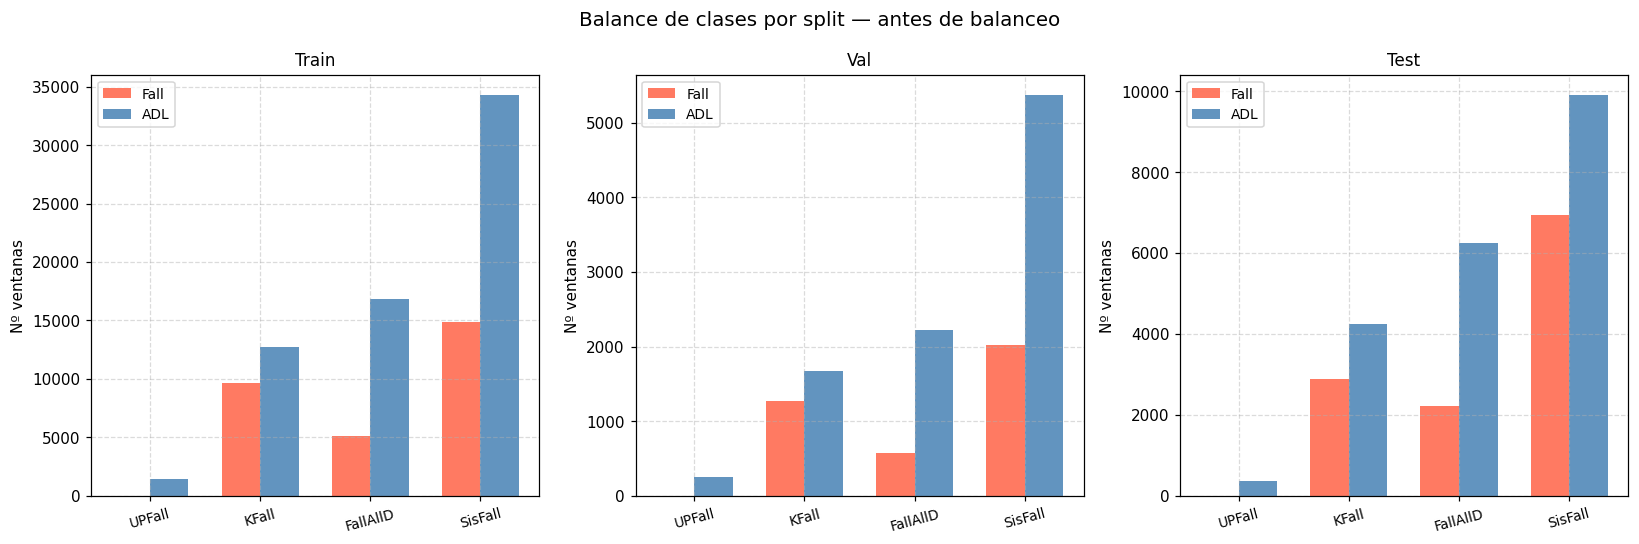

In [27]:
# --- Análisis de balance global -----------------------------------------------
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.linestyle": "--", "grid.alpha": 0.45})

print("\n" + "=" * 75)
print("  BALANCE DE VENTANAS POR SPLIT Y DATASET")
print("=" * 75)
print(df_window_stats.to_string(index=False))

global_agg = df_window_stats.groupby("Split")[["Total", "Fall", "ADL"]].sum()
global_agg["Ratio_ADL_Fall"] = (global_agg["ADL"] / global_agg["Fall"]).round(2)
print("\n  Agregado global (todos los datasets):")
print(global_agg.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Balance de clases por split — antes de balanceo", fontsize=13)

splits = ["train", "val", "test"]
ds_names = list(gold_datasets.keys())
x = np.arange(len(ds_names))
width = 0.35

for ax, split_name in zip(axes, splits):
    sub  = df_window_stats[df_window_stats["Split"] == split_name]
    fall = [sub[sub["Dataset"] == ds]["Fall"].values[0] if ds in sub["Dataset"].values else 0 for ds in ds_names]
    adl  = [sub[sub["Dataset"] == ds]["ADL"].values[0]  if ds in sub["Dataset"].values else 0 for ds in ds_names]

    ax.bar(x - width/2, fall, width, label="Fall",  color="tomato",    alpha=0.85)
    ax.bar(x + width/2, adl,  width, label="ADL",   color="steelblue", alpha=0.85)
    ax.set_title(split_name.capitalize(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(ds_names, rotation=15, fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylabel("Nº ventanas")

plt.tight_layout()
plt.show()

In [28]:
# --- Decisión de estrategia de balanceo (undersampling ADL) -------------------
TARGET_RATIO = 3.0   # objetivo ADL/Fall ≈ 1:3

print(f"Objetivo de ratio ADL/Fall ≤ {TARGET_RATIO:.1f}\n")
print(f"  {'Dataset':12s}  {'Split':6s}  {'Fall':>7}  {'ADL actual':>12}  {'ADL→target':>12}  {'Reducción':>10}")
print("  " + "-" * 58)

undersample_plan = {}

for ds_name in ds_names:
    undersample_plan[ds_name] = {}
    for split_name in splits:
        sub = df_window_stats[
            (df_window_stats["Dataset"] == ds_name) &
            (df_window_stats["Split"]   == split_name)
        ]
        if sub.empty:
            continue

        n_fall = int(sub["Fall"].values[0])
        n_adl  = int(sub["ADL"].values[0])
        target_adl = int(n_fall * TARGET_RATIO)
        target_adl = min(target_adl, n_adl)
        reduction  = (n_adl - target_adl) / n_adl * 100 if n_adl > 0 else 0

        undersample_plan[ds_name][split_name] = {
            "n_fall":      n_fall,
            "n_adl_orig":  n_adl,
            "n_adl_target": target_adl,
        }

        print(
            f"  {ds_name:12s}  {split_name:6s}  {n_fall:>7,}  "
            f"{n_adl:>12,}  {target_adl:>12,}  {reduction:>9.1f}%"
        )

print("\nNota: undersampling aleatorio sobre ventanas ADL por trial (no por muestras).")
print("SMOTE temporal queda como opción de segunda iteración si el modelo no converge.")

Objetivo de ratio ADL/Fall ≤ 3.0

  Dataset       Split      Fall    ADL actual    ADL→target   Reducción
  ----------------------------------------------------------
  UPFall        train         0         1,390             0      100.0%
  UPFall        val           0           244             0      100.0%
  UPFall        test          1           375             3       99.2%
  KFall         train     9,602        12,697        12,697        0.0%
  KFall         val       1,266         1,678         1,678        0.0%
  KFall         test      2,875         4,247         4,247        0.0%
  FallAllD      train     5,130        16,834        15,390        8.6%
  FallAllD      val         570         2,223         1,710       23.1%
  FallAllD      test      2,223         6,251         6,251        0.0%
  SisFall       train    14,889        34,309        34,309        0.0%
  SisFall       val       2,014         5,377         5,377        0.0%
  SisFall       test      6,944         9

In [29]:
# --- Preview rápido del tensor de ventanas (Train combinado) ------------------
print("\nVerificación de shapes de los tensores generados:")
print(f"  {'Dataset':12s}  {'Split':6s}  {'X.shape':>22}  {'y.shape':>14}  {'y dtype':>8}")
print("  " + "-" * 66)

for ds_name, splits_dict in split_windows.items():
    for split_name, (X, y) in splits_dict.items():
        print(
            f"  {ds_name:12s}  {split_name:6s}  "
            f"{str(X.shape):>22}  {str(y.shape):>14}  {str(y.dtype):>8}"
        )

print(f"\n  ✅  Shapes correctos: (N, {WINDOW_SAMPLES}, 6) — {WINDOW_SAMPLES} muestras × 6 canales IMU")


Verificación de shapes de los tensores generados:
  Dataset       Split                  X.shape         y.shape   y dtype
  ------------------------------------------------------------------
  UPFall        train           (1390, 200, 2)         (1390,)      int8
  UPFall        val              (244, 200, 2)          (244,)      int8
  UPFall        test             (376, 200, 2)          (376,)      int8
  KFall         train          (22299, 200, 2)        (22299,)      int8
  KFall         val             (2944, 200, 2)         (2944,)      int8
  KFall         test            (7122, 200, 2)         (7122,)      int8
  FallAllD      train          (21964, 200, 2)        (21964,)      int8
  FallAllD      val             (2793, 200, 2)         (2793,)      int8
  FallAllD      test            (8474, 200, 2)         (8474,)      int8
  SisFall       train          (49198, 200, 2)        (49198,)      int8
  SisFall       val             (7391, 200, 2)         (7391,)      int8
  Si